In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [10]:
import tf_silent
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from pinn_alt import PINN
from network import Network
from optimizer import L_BFGS_B

In [3]:

# # import tensorflow as tf

# # List available CUDA GPUs
# gpus = tf.config.list_physical_devices("GPU")
# print("GPUs:", gpus)


# if gpus:
#     gpu_index = 0
#     tf.config.set_visible_devices(gpus[gpu_index], 'GPU')
#     print("Set visible device to:", gpus[gpu_index])
# else:
#     print("No CUDA GPUs found! Check your CUDA/cuDNN installation and LD_LIBRARY_PATH.")

In [3]:
tf.config.list_logical_devices("GPU")

[]

In [4]:
def mass_cons(network, xy):
    """
    Compute u_x and v_y
    Args:
        xy: network input variables as ndarray.
    Returns:
        (u_x, v_y) as ndarray.
    """

    xy = tf.constant(xy)
    x, y = [ xy[..., i, tf.newaxis] for i in range(xy.shape[-1]) ]
    with tf.GradientTape(persistent=True) as g:
      g.watch(x)
      g.watch(y)

      u_v_p = network(tf.concat([x, y], axis=-1))
      u = u_v_p[..., 0, tf.newaxis]
      v = u_v_p[..., 1, tf.newaxis]
      p = u_v_p[..., 2, tf.newaxis]
    u_x = g.batch_jacobian(u, x)[..., 0]
    v_y = g.batch_jacobian(v, y)[..., 0]

    return u_x.numpy(), v_y.numpy()


In [5]:
def u_0(xy):
    """
    Initial wave form.
    Args:
        tx: variables (t, x) as tf.Tensor.
    Returns:
        u(t, x) as tf.Tensor.
    """

    x = xy[..., 0, None]
    y = xy[..., 1, None]


    return    4*y*(1 - y) 


In [11]:
# if __name__ == '__main__':
"""
Test the physics informed neural network (PINN) model
for the cavity flow governed by the steady Navier-Stokes equation.
"""

# number of training samples
num_train_samples = 4000
# number of test samples
num_test_samples = 200

# inlet flow velocity
u0 = 1
# density
rho = 1
# viscosity
mu = 2.5*1e-2
# Re = (L*u0*rho)/mu ==> rho/mu = 50

# build a core network model
network = Network().build()
network.summary()
# build a PINN model
pinn = PINN(network, rho=rho, mu=mu).build()

# Domain and circle data
x_f =2
x_ini=0
y_f=1
y_ini=0
Cx = 0.5
Cy = 0.5
a = 0.1
b = 0.1

xyt_circle = np.random.rand(num_train_samples, 2)
xyt_circle[...,0] = 2*(a)*xyt_circle[...,0] +(Cx-a)
xyt_circle[0:num_train_samples//2,1] = b*(1 - (xyt_circle[0:num_train_samples//2,0]-Cx)**2 / a**2)**0.5 + Cy
xyt_circle[num_train_samples//2:,1] = -b*(1 - (xyt_circle[num_train_samples//2:,0]-Cx)**2 / a**2)**0.5 + Cy

# create training input
xyt_eqn = np.random.rand(num_train_samples, 2)
xyt_eqn[...,0] = (x_f - x_ini)*xyt_eqn[...,0] + x_ini
xyt_eqn[...,1] = (y_f - y_ini)*xyt_eqn[...,1] + y_ini

for i in range(num_train_samples):
  while (xyt_eqn[i, 0] - Cx)**2/a**2 + (xyt_eqn[i, 1] - Cy)**2/b**2 < 1:
    xyt_eqn[i, 0] = (x_f - x_ini) * np.random.rand(1, 1) + x_ini
    xyt_eqn[i, 1] = (y_f - y_ini) * np.random.rand(1, 1) + y_ini

xyt_w1 = np.random.rand(num_train_samples, 2)  # top-bottom boundaries
xyt_w1[..., 0] = (x_f - x_ini)*xyt_w1[...,0] + x_ini
xyt_w1[..., 1] =  y_ini          # y-position is 0 or 1

xyt_w2 = np.random.rand(num_train_samples, 2)  # top-bottom boundaries
xyt_w2[..., 0] = (x_f - x_ini)*xyt_w2[...,0] + x_ini
xyt_w2[..., 1] =  y_f

xyt_out = np.random.rand(num_train_samples, 2)  # left-right boundaries
xyt_out[..., 0] = x_f

xyt_in = np.random.rand(num_train_samples, 2)
xyt_in[...,0] = x_ini

x_train = [xyt_eqn, xyt_w1, xyt_w2, xyt_out, xyt_in, xyt_circle]

# create training output
zeros = np.zeros((num_train_samples, 3))
#uv_bnd[..., 0] = -u0 * np.floor(xy_bnd[..., 0]) +1
#ones = np.ones((num_train_samples, 3))
#onze = np.random.rand(num_train_samples, 3)
#onze[...,0] = u0
#onze[...,1] = 0
#onze[...,2] = u0
a = u_0(tf.constant(xyt_in)).numpy()
b = np.zeros((num_train_samples, 1))
onze = np.random.permutation(np.concatenate([a,b,a],axis = -1))

y_train = [zeros, onze, zeros, zeros, zeros, zeros]


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 2)]               0         


                                                                 
 dense_5 (Dense)             (None, 48)                144       
                                                                 
 dense_6 (Dense)             (None, 48)                2352      
                                                                 
 dense_7 (Dense)             (None, 48)                2352      
                                                                 
 dense_8 (Dense)             (None, 48)                2352      
                                                                 
 dense_9 (Dense)             (None, 3)                 147       
                                                                 
Total params: 7347 (28.70 KB)
Trainable params: 7347 (28.70 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


L-BFGS-B:   0%|          | 0/30000 [04:34<?, ?iter/s]
/tmp/ipykernel_2555075/1032430158.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xyt_eqn[i, 0] = (x_f - x_ini) * np.random.rand(1, 1) + x_ini
/tmp/ipykernel_2555075/1032430158.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xyt_eqn[i, 1] = (y_f - y_ini) * np.random.rand(1, 1) + y_ini


In [13]:
from optimizer_alt import L_BFGS_B
# train the model using L-BFGS-B algorithm
lbfgs_base = L_BFGS_B(model=pinn, x_train=x_train, y_train=y_train)
lbfgs_base.fit()

Optimizer: L-BFGS-B (maxiter=30000)


L-BFGS-B:  38%|███▊      | 11263/30000 [41:23<1:08:50,  4.54iter/s, loss=0.00482]


In [14]:
model_path = f'base_re40.keras'
network.save(model_path)

In [19]:
def plot_profiles(x, y, u, v, cross_sections):
    """
    Plot velocity profiles (u, v) along specified cross-sections.
    Args:
        x: x-array (meshgrid).
        y: y-array (meshgrid).
        u: u-array (velocity in x-direction).
        v: v-array (velocity in y-direction).
        cross_sections: List of cross-sections to plot. Each cross-section is a tuple (type, value).
                        'type' can be 'x' or 'y', and 'value' is the coordinate value.
                        Example: [('x', 0), ('y', 0), ('y', 1), ('x', 0.75)]
    """
    for section in cross_sections:
        section_type, value = section
        if section_type == 'x':  # Vertical line (constant x)
            idx = np.argmin(np.abs(x[0, :] - value))  # Find the closest x index
            plt.figure(figsize=(8, 6))
            plt.plot(y[:, idx], u[:, idx], label='u (x={})'.format(value))
            plt.plot(y[:, idx], v[:, idx], label='v (x={})'.format(value))
            plt.xlabel('y')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at x = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()
        elif section_type == 'y':  # Horizontal line (constant y)
            idx = np.argmin(np.abs(y[:, 0] - value))  # Find the closest y index
            plt.figure(figsize=(8, 6))
            plt.plot(x[idx, :], u[idx, :], label='u (y={})'.format(value))
            plt.plot(x[idx, :], v[idx, :], label='v (y={})'.format(value))
            plt.xlabel('x')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at y = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()

In [15]:

# create meshgrid coordinates (x, y) for test plots    

x = np.linspace(x_ini, x_f, num_test_samples)
y = np.linspace(y_ini, y_f, num_test_samples)
x, y = np.meshgrid(x, y)
xy = np.stack([x.flatten(), y.flatten()], axis=-1)
# predict (psi, p)
u_v_p = network.predict(xy, batch_size=len(xy))
u, v, p = [ u_v_p[..., i].reshape(x.shape) for i in range(u_v_p.shape[-1]) ]
# compute (u, v)
u = u.reshape(x.shape)
v = v.reshape(x.shape)
p = p.reshape(x.shape)


1/1 [==============================] - 0s 216ms/step


In [16]:
u.shape, v.shape, p.shape, x.shape, y.shape

((200, 200), (200, 200), (200, 200), (200, 200), (200, 200))

In [17]:
def contour(x, y, z, title, levels=200):
    """
    Contour plot.
    Args:
        x: x-array.
        y: y-array.
        z: z-array.
        title: title string.
        levels: number of contour lines.
        circle_center: (x, y) center of the circle.
        circle_radius: radius of the circle.
    """
    circle_center = (0.5, 0.5)
    circle_radius = 0.1
    vmin = np.min(z)
    vmax = np.max(z)
    font1 = {'family':'serif','size':20}
    plt.contour(x, y, z, colors='k', linewidths=0.2, levels=levels)
    plt.contourf(x, y, z, cmap='rainbow', levels=levels, norm=Normalize(vmin=vmin, vmax=vmax))
    ax = plt.gca()
    ax.set_aspect('equal')
    circle = plt.Circle(circle_center, circle_radius, fc='black', zorder=10)
    ax.add_patch(circle)
    plt.title(title, fontdict=font1)
    plt.xlabel("x", fontdict=font1)
    plt.ylabel("y", fontdict=font1)
    plt.tick_params(axis='both', which='major', labelsize=15)
    cbar = plt.colorbar(pad=0.03, aspect=25, format='%.0e')
    cbar.mappable.set_clim(vmin, vmax)
    cbar.ax.tick_params(labelsize=15)

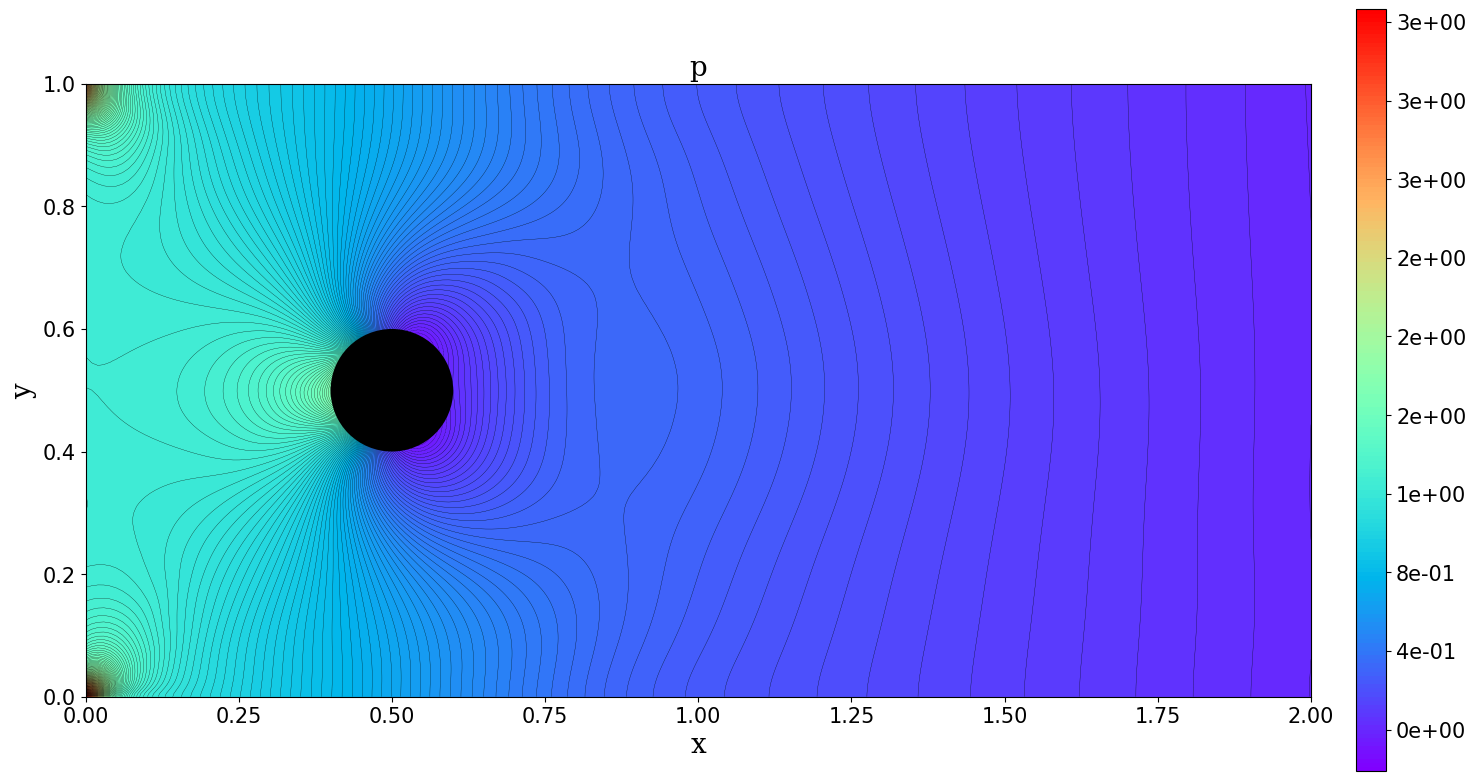

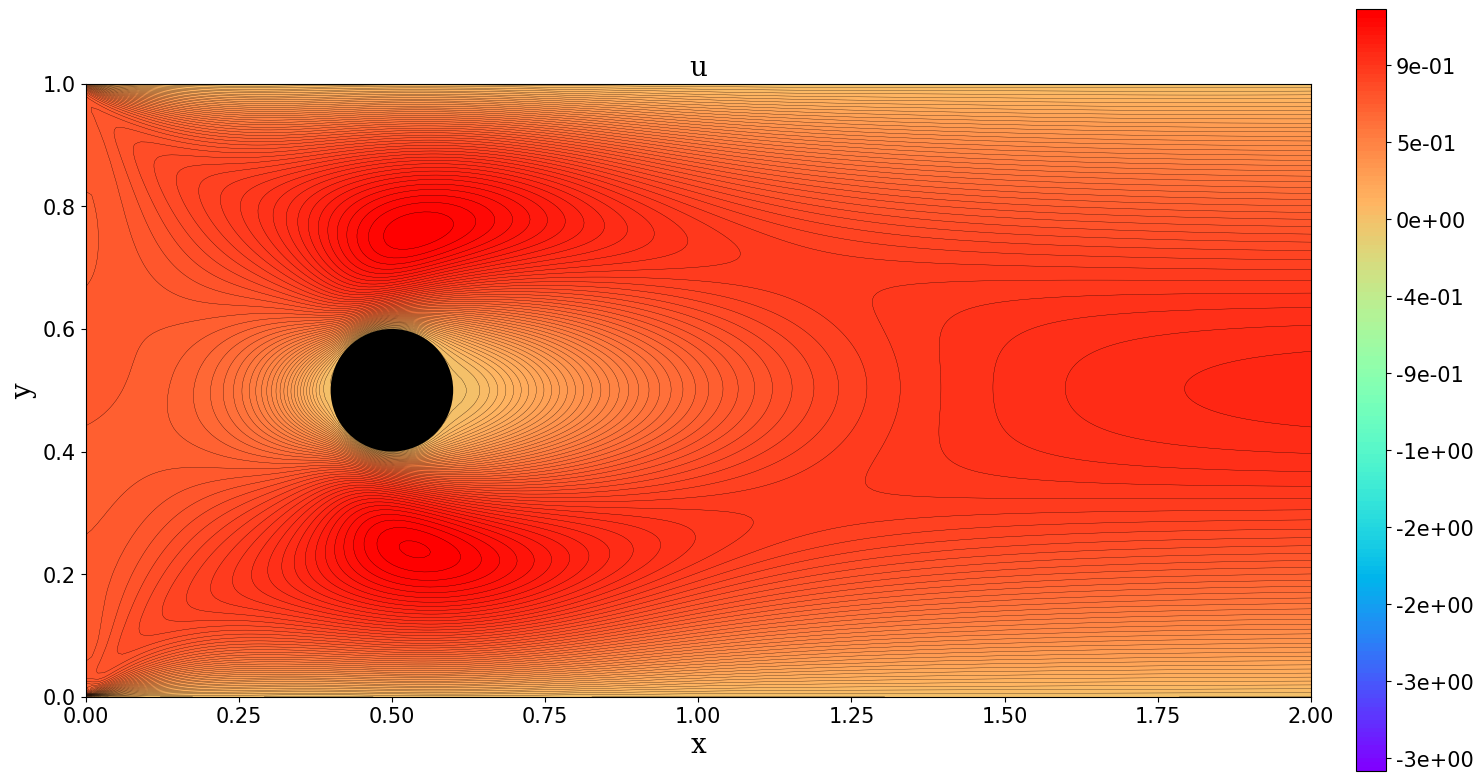

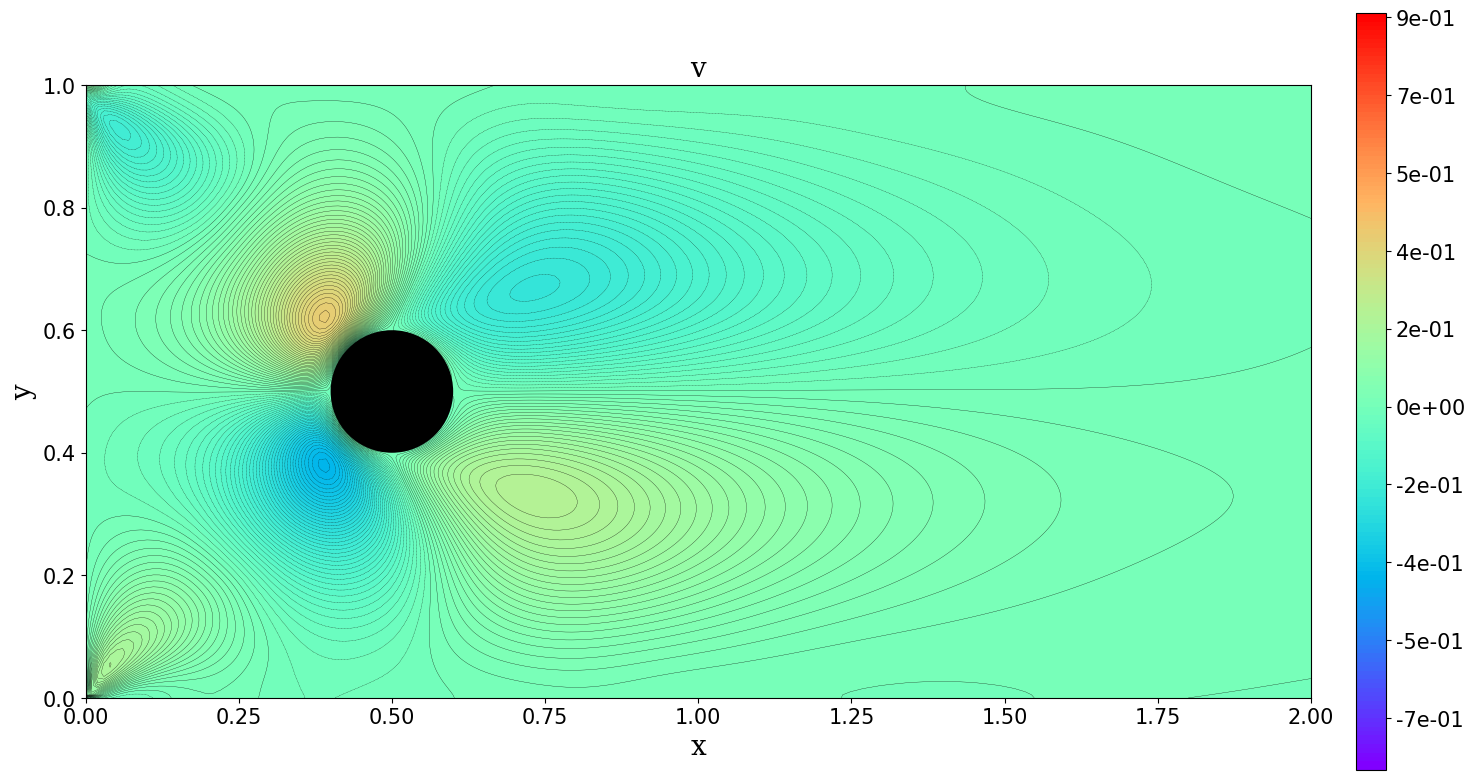

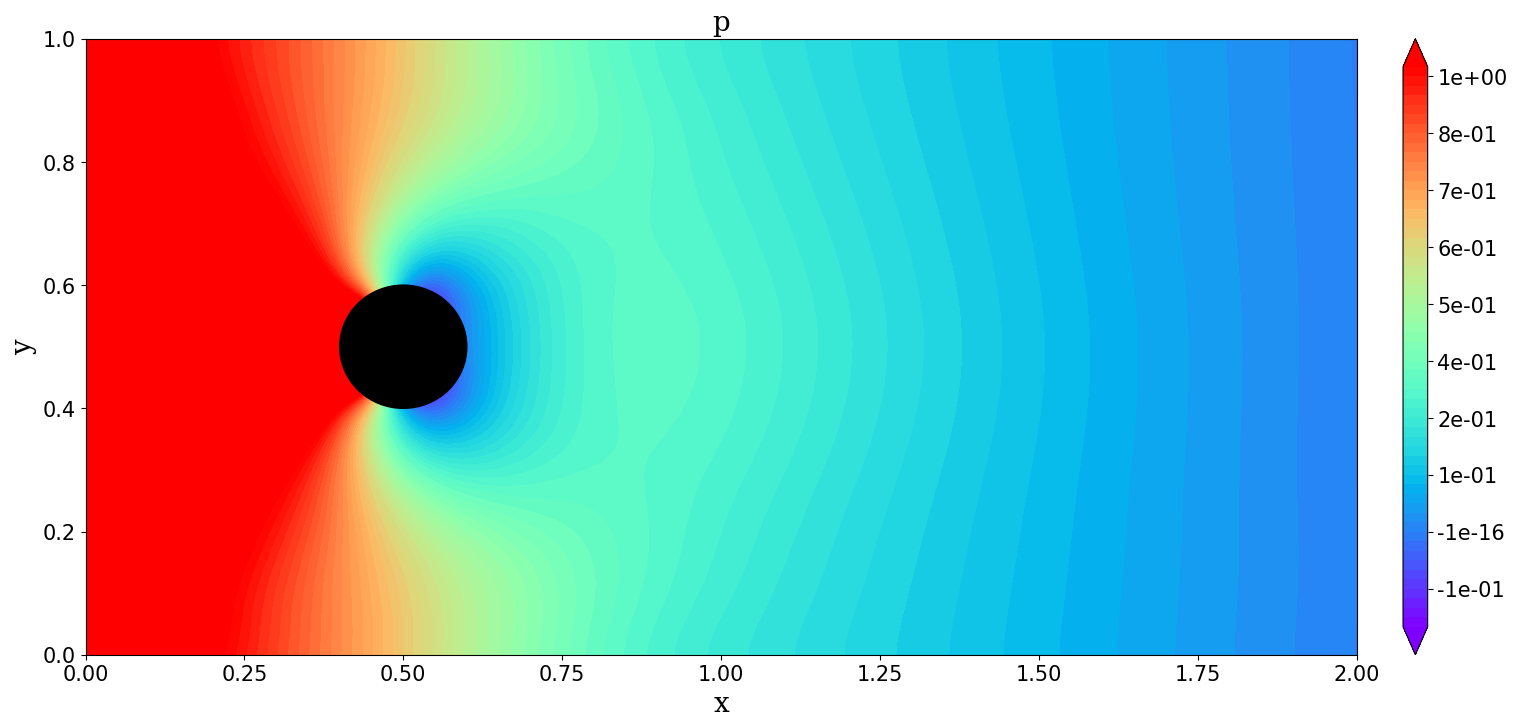

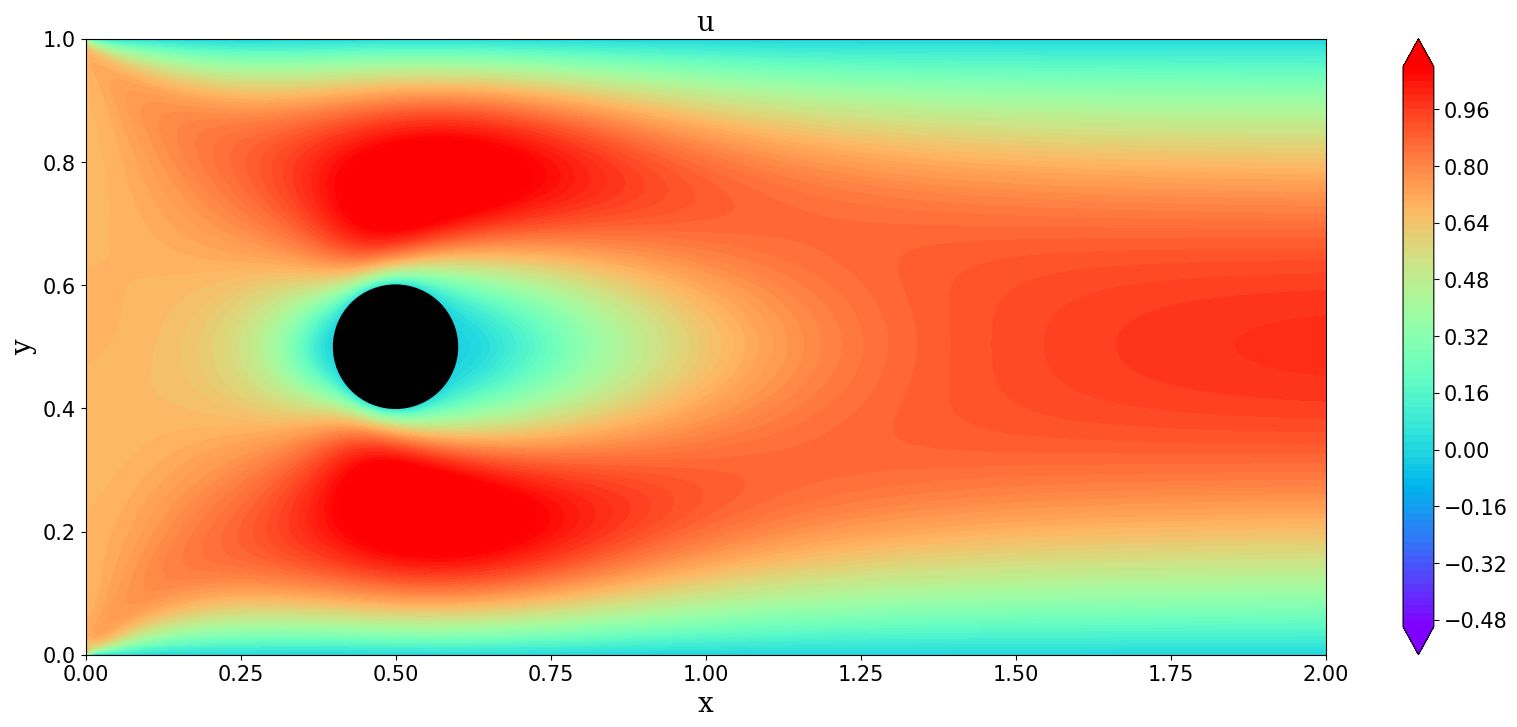

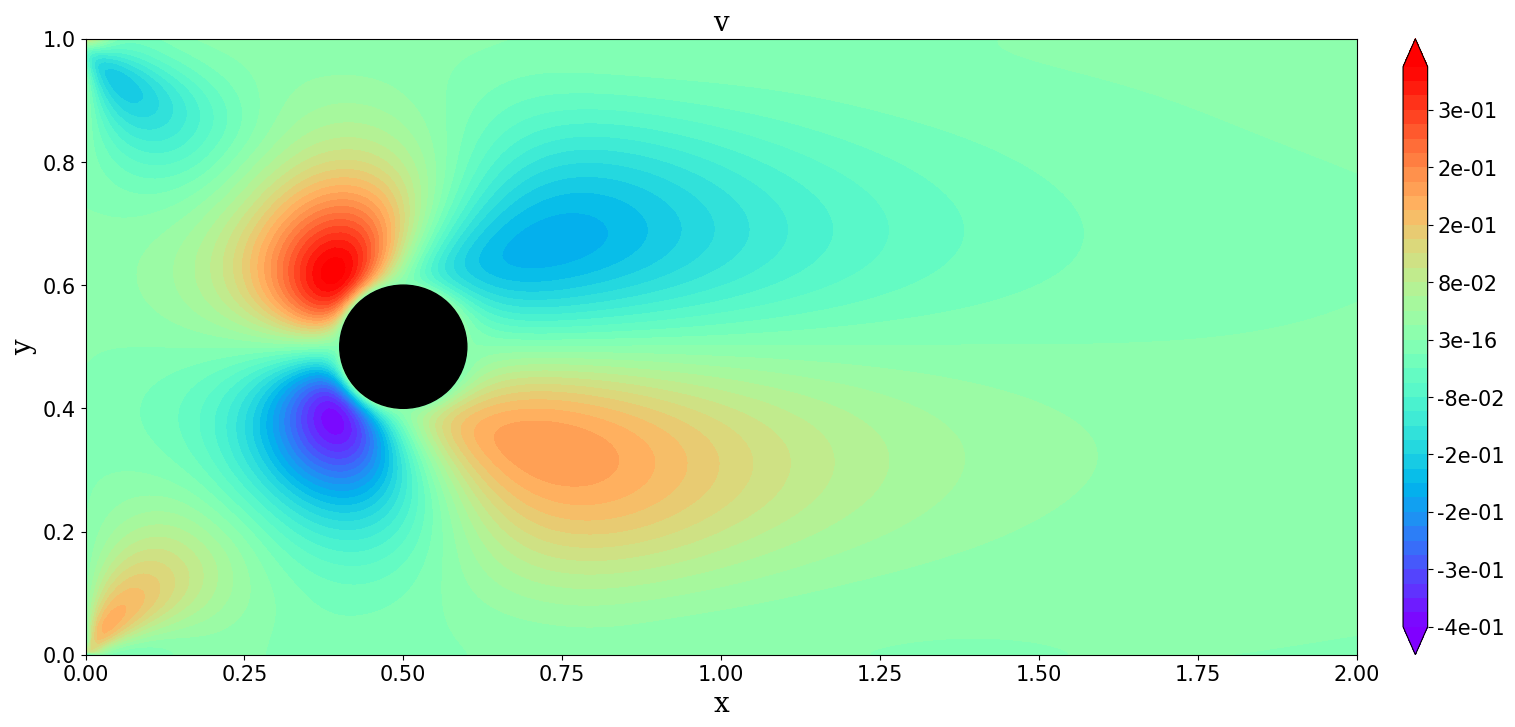

In [18]:

# plot test results
fig = plt.figure(figsize=(16, 8))
contour(x, y, p, 'p')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(16, 8))
contour(x, y, u, 'u')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(16, 8))
contour(x, y, v, 'v')
plt.tight_layout()
plt.show()


###########################
from matplotlib.patches import Circle
font1 = {'family':'serif','size':20}

fig0, ax0 = plt.subplots(1, 1,figsize=(20,8))
cf0 = ax0.contourf(x, y, p, np.arange(-0.2, 1, .02),
                extend='both',cmap='rainbow')
cbar0 = plt.colorbar(cf0, pad=0.03, aspect=25, format='%.0e')
plt.title("p", fontdict = font1)
plt.xlabel("x", fontdict = font1)
plt.ylabel("y", fontdict = font1)
ax0.add_patch(Circle((0.5, 0.5), 0.1,color="black"))
plt.tick_params(axis='both', which='major', labelsize=15)
cbar0.ax.tick_params(labelsize=15)
plt.show()

###########################

fig0, ax0 = plt.subplots(1, 1, figsize=(20,8))
cf0 = ax0.contourf(x, y, u, np.arange(-0.5, 1.1, .02),
                extend='both',cmap='rainbow')
cbar0 = plt.colorbar(cf0, )
plt.title("u", fontdict = font1)
plt.xlabel("x", fontdict = font1)
plt.ylabel("y", fontdict = font1)
ax0.add_patch(Circle((0.5, 0.5), 0.1,color="black"))
plt.tick_params(axis='both', which='major', labelsize=15)
cbar0.ax.tick_params(labelsize=15)
plt.show()

###########################

fig0, ax0 = plt.subplots(1, 1,figsize=(20,8))
cf0 = ax0.contourf(x, y, v, np.arange(-0.4, 0.4, .02),
                extend='both',cmap='rainbow')
cbar0 = plt.colorbar(cf0, pad=0.03, aspect=25, format='%.0e')
plt.title("v", fontdict = font1)
plt.xlabel("x", fontdict = font1)
plt.ylabel("y", fontdict = font1)
ax0.add_patch(Circle((0.5, 0.5), 0.1,color="black"))
plt.tick_params(axis='both', which='major', labelsize=15)
cbar0.ax.tick_params(labelsize=15)
plt.show()

############################ 


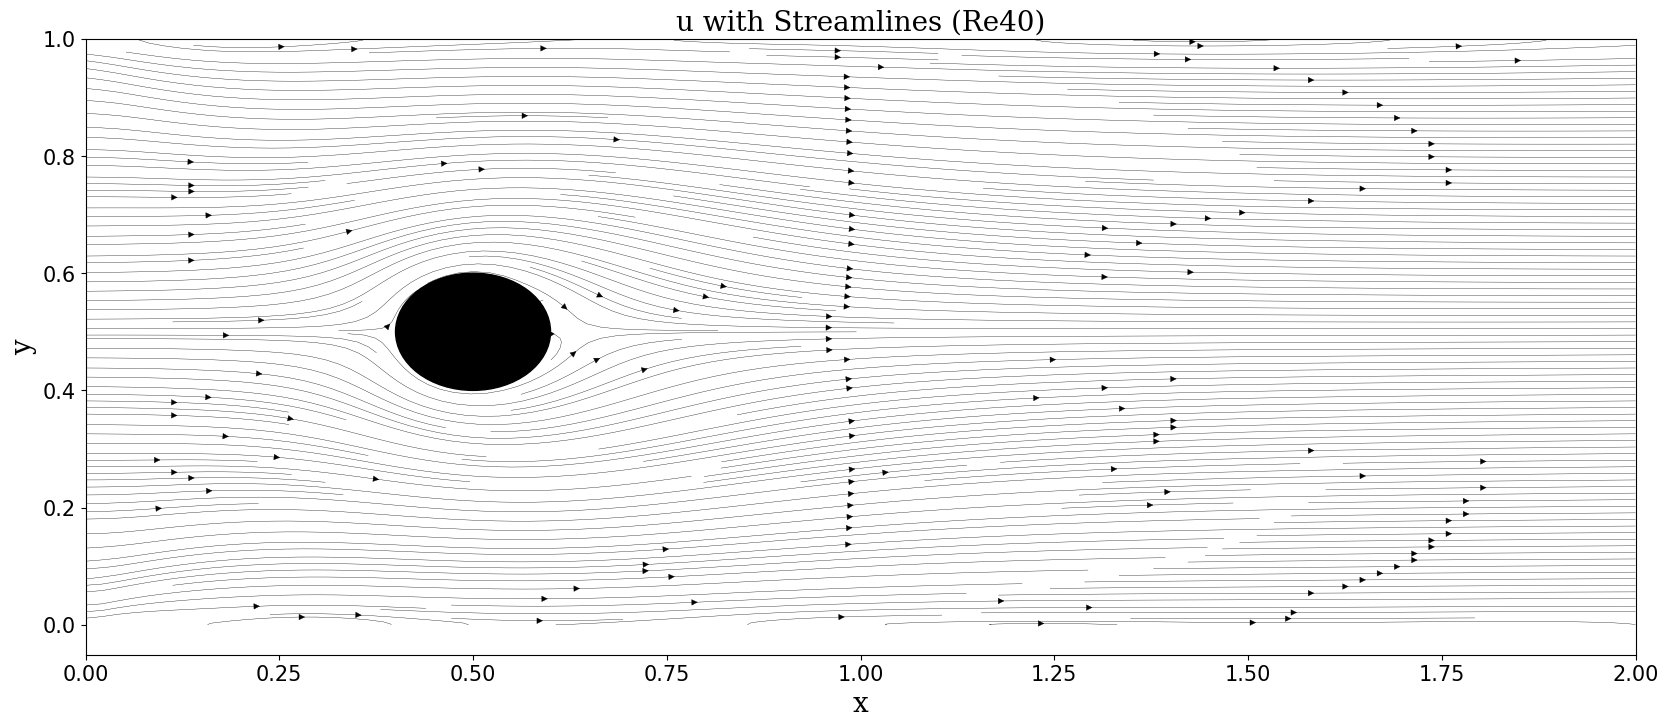

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

font1 = {'family':'serif','size':20}

fig, ax = plt.subplots(1, 1, figsize=(20, 8))
# Contourf for pressure (or any scalar field)
# cf = ax.contourf(x, y, u, np.arange(-0.2, 1, .02), extend='both', cmap='rainbow')
# cbar = plt.colorbar(cf, pad=0.03, aspect=25, format='%.0e')
# Streamlines for velocity field
strm = ax.streamplot(x, y, u, v, color='k', density=3, linewidth=0.25)
# Add cylinder
ax.add_patch(Circle((0.5, 0.5), 0.1, color="black"))
plt.title("u with Streamlines (Re40)", fontdict=font1)
plt.xlabel("x", fontdict=font1)
plt.ylabel("y", fontdict=font1)
plt.tick_params(axis='both', which='major', labelsize=15)
# cbar.ax.tick_params(labelsize=15)
plt.savefig('u_streamlines_Re40_base.png', dpi=300)
plt.show()

In [21]:
def plot_profiles(x, y, u, v, cross_sections, save_csv=False, prefix="u10", location="data/pinn_profiles/"):
    """
    Plot velocity profiles (u, v) along specified cross-sections and optionally save u profiles to CSV.
    Args:
        x: x-array (meshgrid).
        y: y-array (meshgrid).
        u: u-array (velocity in x-direction).
        v: v-array (velocity in y-direction).
        cross_sections: List of cross-sections to plot. Each cross-section is a tuple (type, value).
        save_csv: If True, save u profiles to CSV files.
        prefix: Prefix for CSV filenames.
    """
    for section in cross_sections:
        section_type, value = section
        if section_type == 'x':  # Vertical line (constant x)
            idx = np.argmin(np.abs(x[0, :] - value))  # Find the closest x index
            plt.figure(figsize=(8, 6))
            plt.plot(y[:, idx], u[:, idx], label='u (x={})'.format(value))
            plt.plot(y[:, idx], v[:, idx], label='v (x={})'.format(value))
            plt.xlabel('y')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at x = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()
            if save_csv:
                # Save u profile: y as 'x', u as 'u'
                df = pd.DataFrame({'x': y[:, idx], 'u': u[:, idx]})
                filename = f"{prefix}_{value}.csv"
                df.to_csv(location+prefix+"/"+filename, index=False)
        elif section_type == 'y':  # Horizontal line (constant y)
            idx = np.argmin(np.abs(y[:, 0] - value))  # Find the closest y index
            plt.figure(figsize=(8, 6))
            plt.plot(x[idx, :], u[idx, :], label='u (y={})'.format(value))
            plt.plot(x[idx, :], v[idx, :], label='v (y={})'.format(value))
            plt.xlabel('x')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at y = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()
            if save_csv:
                # Save u profile: x as 'x', u as 'u'
                df = pd.DataFrame({'x': x[idx, :], 'u': u[idx, :]})
                filename = f"{prefix}_y{value}.csv"
                df.to_csv(location+prefix+"/"+filename, index=False)

In [22]:
def plot_profiles(x, y, u, v, cross_sections):
    """
    Plot velocity profiles (u, v) along specified cross-sections.
    Args:
        x: x-array (meshgrid).
        y: y-array (meshgrid).
        u: u-array (velocity in x-direction).
        v: v-array (velocity in y-direction).
        cross_sections: List of cross-sections to plot. Each cross-section is a tuple (type, value).
                        'type' can be 'x' or 'y', and 'value' is the coordinate value.
                        Example: [('x', 0), ('y', 0), ('y', 1), ('x', 0.75)]
    """
    for section in cross_sections:
        section_type, value = section
        if section_type == 'x':  # Vertical line (constant x)
            idx = np.argmin(np.abs(x[0, :] - value))  # Find the closest x index
            plt.figure(figsize=(8, 6))
            plt.plot(y[:, idx], u[:, idx], label='u (x={})'.format(value))
            plt.plot(y[:, idx], v[:, idx], label='v (x={})'.format(value))
            plt.xlabel('y')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at x = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()
        elif section_type == 'y':  # Horizontal line (constant y)
            idx = np.argmin(np.abs(y[:, 0] - value))  # Find the closest y index
            plt.figure(figsize=(8, 6))
            plt.plot(x[idx, :], u[idx, :], label='u (y={})'.format(value))
            plt.plot(x[idx, :], v[idx, :], label='v (y={})'.format(value))
            plt.xlabel('x')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at y = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()

In [ ]:
# Plot velocity profiles along specified cross-sections
import pandas as pd
cross_sections = [
    ('x', 0.30),
    ('x', 0.35),
    ('x', 0.40),
    ('x', 0.45),
    ('x', 0.50),
    ('x', 0.55),
    ('x', 0.60),
    ('x', 0.65),
    ('x', 0.70),
    ('x', 0.75),
]
plot_profiles(x, y, u, v, cross_sections, save_csv=True, prefix="u40", location="data/pinn_profiles/")


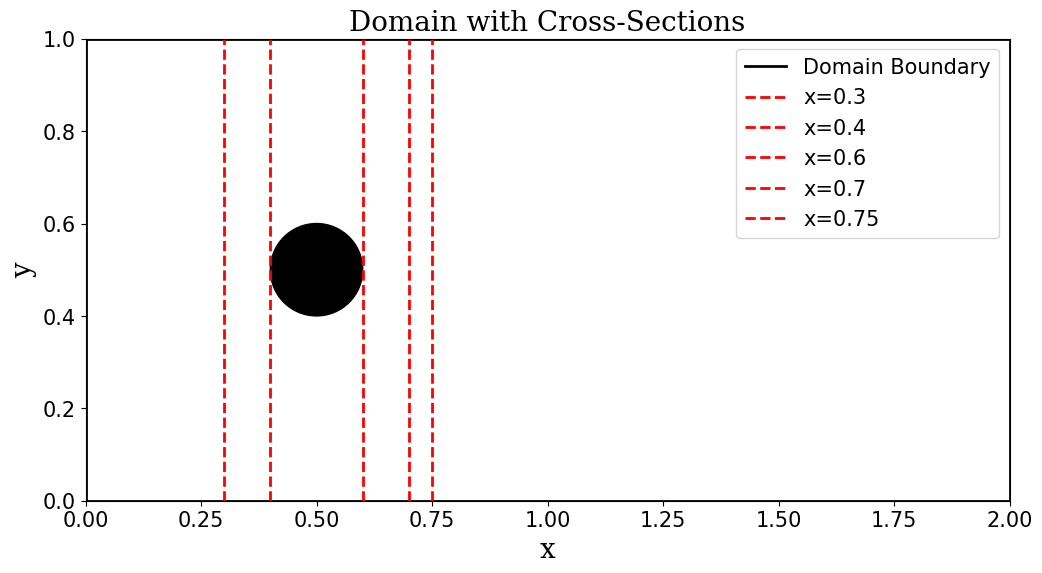

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

font1 = {'family':'serif','size':20}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
# Draw domain boundary (rectangle)
ax.plot([0, 2, 2, 0, 0], [0, 0, 1, 1, 0], color='black', linewidth=2, label='Domain Boundary')
# Draw cylinder
ax.add_patch(Circle((0.5, 0.5), 0.1, color="black"))

# Cross-section x lines to plot
cs_x = [0.3, 0.4, 0.6, 0.7, 0.75]
for value in cs_x:
    ax.axvline(value, color='red', linestyle='--', linewidth=2, label=f'x={value}')

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=15)

plt.title("Domain with Cross-Sections", fontdict=font1)
plt.xlabel("x", fontdict=font1)
plt.ylabel("y", fontdict=font1)
plt.xlim(0, 2)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("domain_with_cs_lines.png", dpi=300, bbox_inches='tight')
plt.show()


In [20]:
! pip install pandas

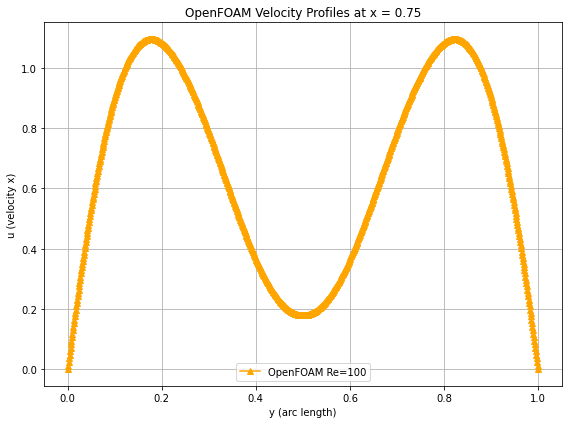

In [ ]:

import pandas as pd

ux_re40_truth = "/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison/Re40_coarse_cs"

# Read CSVs (assume columns: arc_length, U_X)
df_re40_truth = pd.read_csv(ux_re40_truth)

# Plot OpenFOAM velocity profiles at x=0.75 for different Reynolds numbers
plt.figure(figsize=(8, 6))
# plt.plot(df_re10["arc_length"], df_re10["U_X"], label="OpenFOAM Re=10", color="green", marker="o")
plt.plot(df_re100["arc_length"], df_re100["U_X"], label="OpenFOAM Re=100", color="orange", marker="^")
# plt.plot(df_re1000["arc_length"], df_re1000["U_X"], label="OpenFOAM Re=1000", color="red", marker="s")
plt.xlabel("y (arc length)")
plt.ylabel("u (velocity x)")
plt.title("OpenFOAM Velocity Profiles at x = 0.75")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# my model improvements on top of hte base model 
# PINN_with_OF = /mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison/OF_manual_lossset_02.keras
# PINN_with_SIREN = /mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison/SIREN_manual_lossset_03.keras
# PINN_implicit = /mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison/implicit_noroi_LC_cyl60.keras
# Base_model = /mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison/base_re40.keras
ux_re40_truth = "/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison/Re40_coarse_cs"

# Read CSVs (assume columns: arc_length, U_X)
df_re40_truth = pd.read_csv(ux_re40_truth)

def analyze_all_models(model_dir):
    model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])
    results = []
    for model_file in model_files:
        model_path = os.path.join(model_dir, model_file)
        print(f"Analyzing {model_file}")
        network = tf.keras.models.load_model(model_path)
        x = np.linspace(0, 2, 300)
        y = np.linspace(0, 1, 300)
        x_grid, y_grid = np.meshgrid(x, y)
        xy_flat = np.stack([x_grid.flatten(), y_grid.flatten()], axis=-1)
        u_v_p = network.predict(xy_flat, batch_size=len(xy_flat))
        u = u_v_p[..., 0].reshape(x_grid.shape)
        v = u_v_p[..., 1].reshape(x_grid.shape)
        p = u_v_p[..., 2].reshape(x_grid.shape)
        metrics = enhanced_wake_metrics(x_grid, y_grid, u, v, p, model_name=model_file)
        results.append(metrics)
    return pd.DataFrame(results)

def plot_profile_comparison(y_pinn, u_pinn, y_ref, u_ref, label_pinn="PINN", label_ref="OpenFOAM", title="Velocity Profile Comparison"):
    """
    Plot and compare two velocity profiles along the same cross-section.
    Args:
        y_pinn: y-coordinates for PINN data.
        u_pinn: velocity values for PINN data.
        y_ref: y-coordinates for reference data (e.g., OpenFOAM).
        u_ref: velocity values for reference data.
        label_pinn: label for PINN data.
        label_ref: label for reference data.
        title: plot title.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(y_pinn, u_pinn, label=label_pinn, color='blue')
    plt.plot(y_ref, u_ref, label=label_ref, color='orange')
    plt.xlabel('y (arc length)')
    plt.ylabel('u (velocity x)')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


# List of cross-sections of interest
cross_sections = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

for x_target in cross_sections:
    idx = np.argmin(np.abs(x[0, :] - x_target))
    y_pinn = y[:, idx]
    u_pinn = u[:, idx]
    # Load OpenFOAM reference data for this cross-section
    # Assumes file naming: data/Re10_cs/Re10_coarse_{x_target}.csv
    fname = f"Re40_coarse_cs/Re40_coarse_{x_target}.csv"
    try:
        df_re = pd.read_csv(fname)
        y_ref = df_re["arc_length"]
        u_ref = df_re["U_X"]
        plot_profile_comparison(
            y_pinn, u_pinn, y_ref, u_ref,
            label_pinn="PINN",
            label_ref="OpenFOAM",
            title=f"RE:40, u Profile at x={x_target}"
        )
    except FileNotFoundError:
        print(f"Reference file not found: {fname}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

cross_sections = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
axes = axes.flatten()

for i, x_target in enumerate(cross_sections):
    idx = np.argmin(np.abs(x[0, :] - x_target))
    y_pinn = y[:, idx]
    u_pinn = u[:, idx]
    fname = f"data/Re40_coarse_cs/Re40_coarse_{x_target}.csv"
    try:
        df_re = pd.read_csv(fname)
        y_ref = df_re["arc_length"]
        u_ref = df_re["U_X"]
        axes[i].plot(y_pinn, u_pinn, label="PINN", color='blue')
        axes[i].plot(y_ref, u_ref, label="OpenFOAM", color='orange')
        axes[i].set_title(f"x={x_target}")
        axes[i].set_xlabel("y")
        if i % 5 == 0:
            axes[i].set_ylabel("u")
        axes[i].grid()
        if i == 0:
            axes[i].legend()
    except FileNotFoundError:
        axes[i].set_title(f"x={x_target}\nNo ref data")
        axes[i].set_xlabel("y")
        if i % 5 == 0:
            axes[i].set_ylabel("u")
        axes[i].grid()

plt.suptitle("Velocity Profile Comparison (PINN vs OpenFOAM)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("profile_comparison_40.png", dpi=300)  # Save as high-res image
plt.show()

In [37]:
import numpy as np
from scipy.interpolate import interp1d

# y_pinn, u_pinn: PINN y and u values at x=0.75
# y_ref, u_ref: OpenFOAM y and u values at x=0.75

# Interpolate PINN profile onto OpenFOAM's y-coordinates
u_pinn_interp = interp1d(y_pinn, u_pinn, kind='linear', bounds_error=False, fill_value='extrapolate')
u_pinn_on_ref = u_pinn_interp(y_ref)

# Compute errors
mae = np.mean(np.abs(u_pinn_on_ref - u_ref))
rmse = np.sqrt(np.mean((u_pinn_on_ref - u_ref)**2))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.0741
RMSE: 0.0903


In [32]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

cross_sections = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
results = []

for x_target in cross_sections:
    idx = np.argmin(np.abs(x[0, :] - x_target))
    y_pinn = y[:, idx]
    u_pinn = u[:, idx]
    fname = f"data/Re10_cs/Re10_coarse_{x_target}.csv"
    try:
        df_re = pd.read_csv(fname)
        y_ref = df_re["arc_length"]
        u_ref = df_re["U_X"]
        # Interpolate PINN profile onto OpenFOAM's y-coordinates
        u_pinn_interp = interp1d(y_pinn, u_pinn, kind='linear', bounds_error=False, fill_value='extrapolate')
        u_pinn_on_ref = u_pinn_interp(y_ref)
        # Compute errors
        mae = np.mean(np.abs(u_pinn_on_ref - u_ref))
        rmse = np.sqrt(np.mean((u_pinn_on_ref - u_ref)**2))
        results.append({'cs': x_target, 'mae': mae, 'rmse': rmse})
    except FileNotFoundError:
        results.append({'cs': x_target, 'mae': np.nan, 'rmse': np.nan})

# Create and display table
df_results = pd.DataFrame(results)
print(df_results)

     cs       mae      rmse
0  0.30  0.136180  0.150163
1  0.35  0.111169  0.121765
2  0.40  0.084424  0.096820
3  0.45  0.071235  0.081116
4  0.50  0.047781  0.055446
5  0.55  0.027798  0.034631
6  0.60  0.018148  0.024958
7  0.65  0.021634  0.025752
8  0.70  0.026311  0.029829
9  0.75  0.029056  0.033258


In [33]:
df_results.describe()

,cs,mae,rmse
count,10.000000,10.000000,10.000000
mean,0.525000,0.057374,0.065374
std,0.151383,0.041604,0.044904
min,0.300000,0.018148,0.024958
25%,0.412500,0.026683,0.030686
50%,0.525000,0.038419,0.045038
75%,0.637500,0.081127,0.092894
max,0.750000,0.136180,0.150163


In [34]:
df_results.to_csv("data/Re40_coarse_errors.csv", index=False)

1/1 [==============================] - 0s 110ms/step


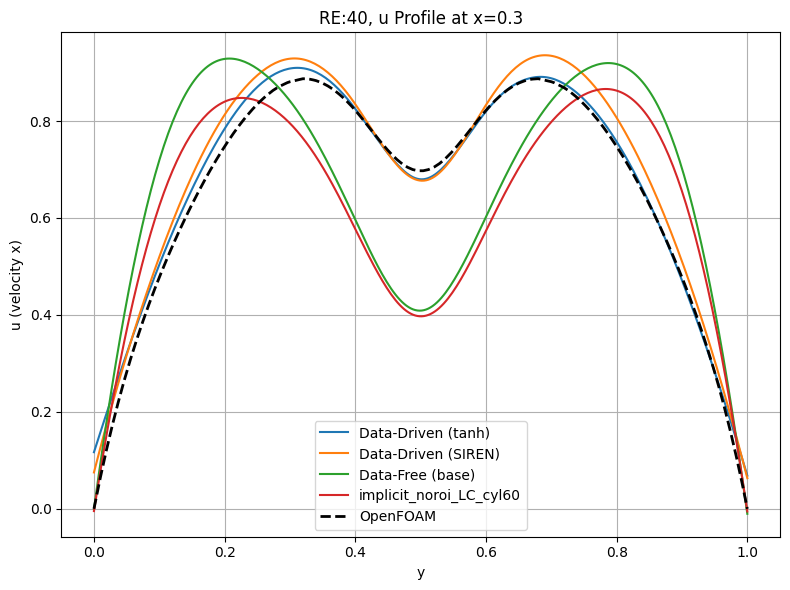

1/1 [==============================] - 0s 76ms/step


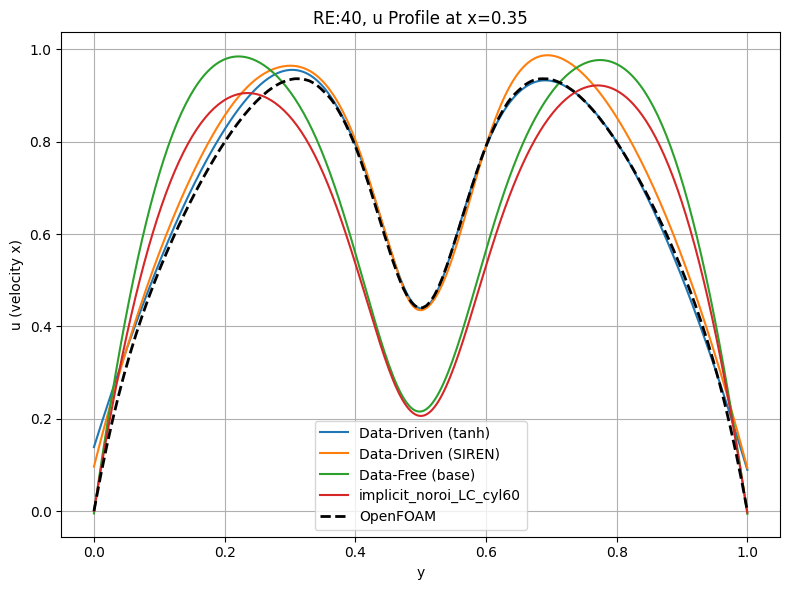

1/1 [==============================] - 0s 84ms/step


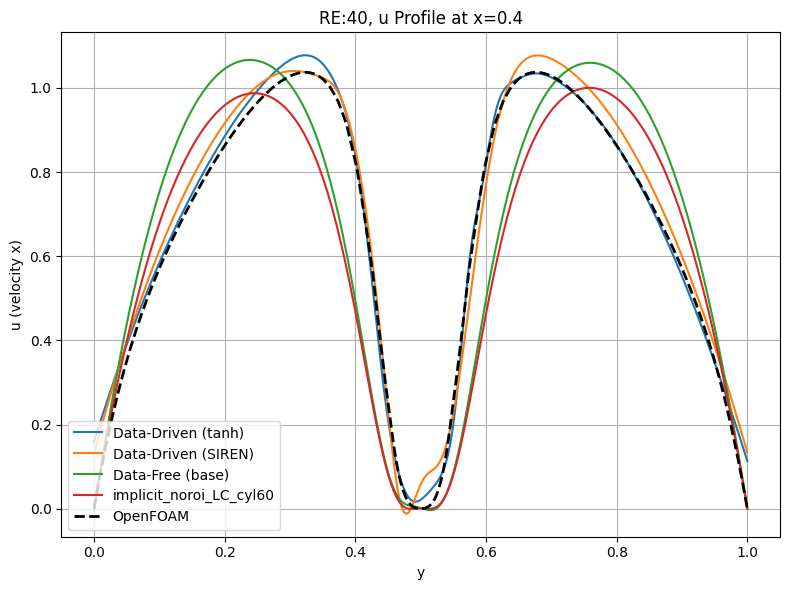

1/1 [==============================] - 0s 78ms/step


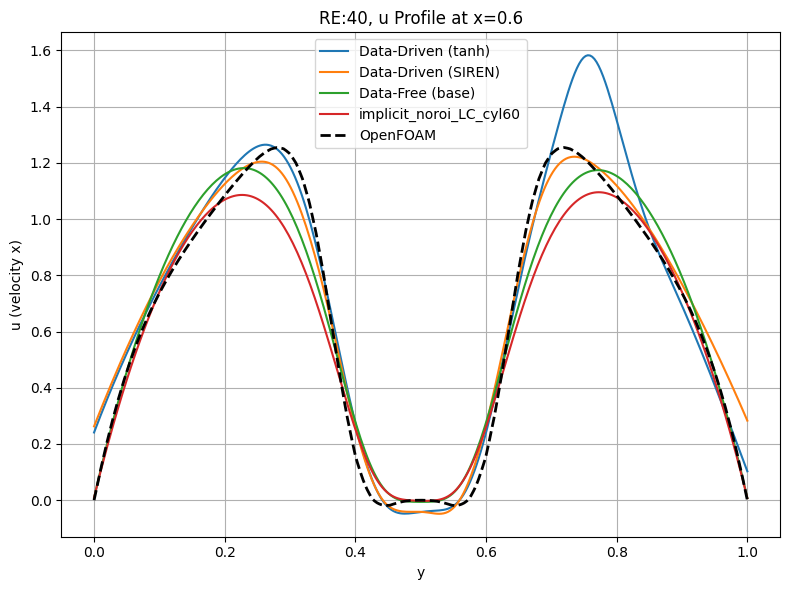

1/1 [==============================] - 0s 82ms/step


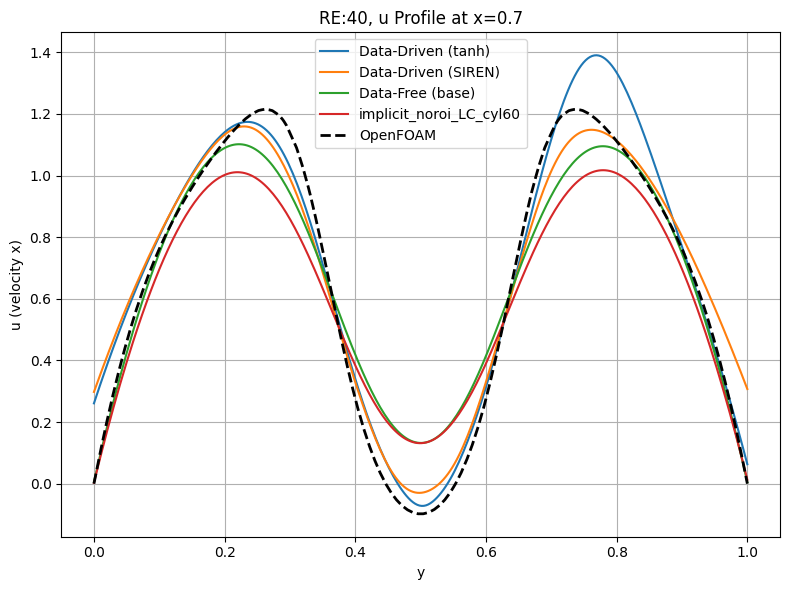

1/1 [==============================] - 0s 77ms/step


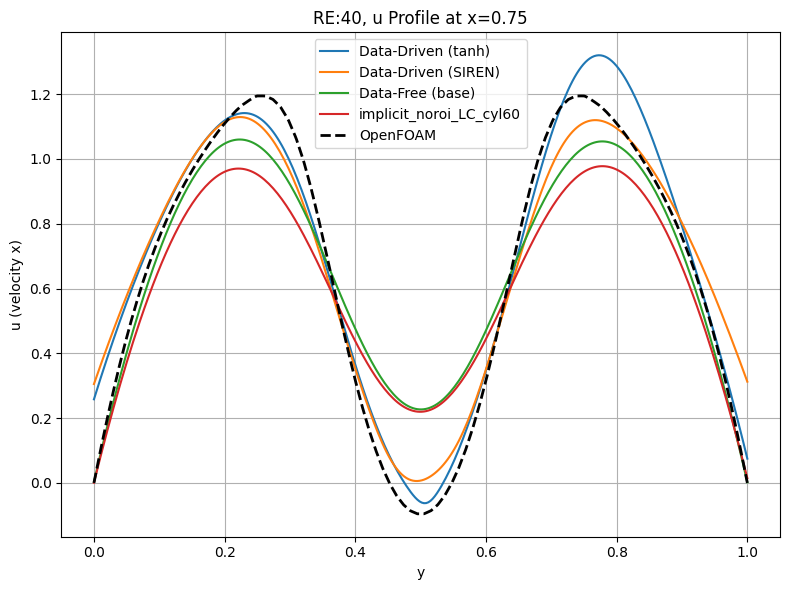

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

model_dir = "/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison"
cross_sections = [0.3, 0.35, 0.4, 0.6, 0.7, 0.75]
model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])
legend_labels = {
    "OF_manual_lossset_02": "Data-Driven (tanh)",
    "SIREN_manual_lossset_03": "Data-Driven (SIREN)",
    "implicit_noroi_LC_cyl10": "Data-Free (weighted-loss)",
    "base_re40": "Data-Free (base)"
}
x = np.linspace(0, 2, 300)
y = np.linspace(0, 1, 300)
x_grid, y_grid = np.meshgrid(x, y)

for x_target in cross_sections:
    plt.figure(figsize=(8, 6))
    # Plot each model
    for model_file in model_files:
        network = tf.keras.models.load_model(os.path.join(model_dir, model_file))
        xy_flat = np.stack([x_grid.flatten(), y_grid.flatten()], axis=-1)
        u_v_p = network.predict(xy_flat, batch_size=len(xy_flat))
        u = u_v_p[..., 0].reshape(x_grid.shape)
        idx = np.argmin(np.abs(x_grid[0, :] - x_target))
        y_pinn = y_grid[:, idx]
        u_pinn = u[:, idx]
        model_name = model_file.replace('.keras','')
        label = legend_labels.get(model_name, model_name)
        plt.plot(y_pinn, u_pinn, label=label)
    # Plot OpenFOAM reference
    fname = f"Re40_coarse_cs/Re40_coarse_{x_target}.csv"
    try:
        df_re = pd.read_csv(fname)
        y_ref = df_re["arc_length"]
        u_ref = df_re["U_X"]
        plt.plot(y_ref, u_ref, label="OpenFOAM", color='black', linewidth=2, linestyle='--')
    except FileNotFoundError:
        print(f"Reference file not found: {fname}")
    plt.xlabel('y')
    plt.ylabel('u (velocity x)')
    plt.title(f"RE:40, u Profile at x={x_target}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"all_models_profile_x{x_target}.png", dpi=200)
    plt.show()

In [44]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.interpolate import interp1d

# Define paths and configuration
model_dir = "/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison"
cross_sections = [0.3, 0.35, 0.4, 0.6, 0.7, 0.75]
model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])
legend_labels = {
    "OF_manual_lossset_02": "Data-Driven (tanh)",
    "SIREN_manual_lossset_03": "Data-Driven (SIREN)",
    "implicit_noroi_LC_cyl10": "Data-Free (weighted-loss)",
    "base_re40": "Data-Free (base)"
}

# Initialize mesh grid
x = np.linspace(0, 2, 300)
y = np.linspace(0, 1, 300)
x_grid, y_grid = np.meshgrid(x, y)

# Dictionary to store metrics for all models
all_metrics = {model_file.replace('.keras',''): [] for model_file in model_files}

# For each cross section
for x_target in cross_sections:
    # Load reference data
    try:
        fname = f"Re40_coarse_cs/Re40_coarse_{x_target}.csv"
        df_re = pd.read_csv(fname)
        y_ref = df_re["arc_length"]
        u_ref = df_re["U_X"]
        
        # For each model
        for model_file in model_files:
            network = tf.keras.models.load_model(os.path.join(model_dir, model_file))
            xy_flat = np.stack([x_grid.flatten(), y_grid.flatten()], axis=-1)
            u_v_p = network.predict(xy_flat, batch_size=len(xy_flat))
            u = u_v_p[..., 0].reshape(x_grid.shape)
            idx = np.argmin(np.abs(x_grid[0, :] - x_target))
            y_pinn = y_grid[:, idx]
            u_pinn = u[:, idx]
            
            # Mask out points inside the cylinder
            mask = ((x_target - 0.5)**2 + (y_pinn - 0.5)**2) >= 0.1**2
            y_pinn_masked = y_pinn[mask]
            u_pinn_masked = u_pinn[mask]
            
            # Calculate metrics
            # 1. Interpolate PINN values to reference y coordinates
            u_pinn_interp = interp1d(y_pinn_masked, u_pinn_masked, bounds_error=False, fill_value="extrapolate")
            mask_ref = ((x_target - 0.5)**2 + (y_ref - 0.5)**2) >= 0.1**2
            y_ref_masked = y_ref[mask_ref]
            u_ref_masked = u_ref[mask_ref]
            u_pinn_on_ref = u_pinn_interp(y_ref_masked)
            
            # 2. Calculate metrics
            mae = np.mean(np.abs(u_pinn_on_ref - u_ref_masked))
            rmse = np.sqrt(np.mean((u_pinn_on_ref - u_ref_masked)**2))
            max_diff = np.max(np.abs(u_pinn_on_ref - u_ref_masked))
            peak_u_pinn = np.max(u_pinn_masked)
            peak_u_ref = np.max(u_ref_masked)
            peak_diff = np.abs(peak_u_pinn - peak_u_ref)
            
            model_name = model_file.replace('.keras','')
            
            # Store metrics
            all_metrics[model_name].append({
                "cross_section": x_target,
                "MAE": mae,
                "RMSE": rmse,
                "max_diff": max_diff,
                "peak_diff": peak_diff
            })
    
    except FileNotFoundError:
        print(f"Reference file not found: {fname}")

# Create summary tables for each metric
summary_tables = {}
for metric_name in ["MAE", "RMSE", "max_diff", "peak_diff"]:
    data = []
    for model_file in model_files:
        model_name = model_file.replace('.keras','')
        model_label = legend_labels.get(model_name, model_name)
        row = {"Model": model_label}
        
        for metrics in all_metrics[model_name]:
            row[f"x={metrics['cross_section']}"] = metrics[metric_name]
        
        # Calculate mean across all cross sections
        metric_values = [metrics[metric_name] for metrics in all_metrics[model_name]]
        row["Mean"] = np.mean(metric_values)
        
        data.append(row)
    
    # Create DataFrame and sort by mean value
    df = pd.DataFrame(data)
    df = df.sort_values(by="Mean")
    summary_tables[metric_name] = df

# Display summary tables
for metric_name, df in summary_tables.items():
    print(f"\n{metric_name} Summary:")
    print(df.to_string(index=False))
    
    # Save to CSV
    df.to_csv(f"summary_{metric_name.lower()}.csv", index=False)

# Create focused tables for specific cross-sections of interest
focus_cross_sections = [0.35, 0.75]  # Before and after cylinder

for x_target in focus_cross_sections:
    # Create a table for this specific cross-section
    data = []
    for model_file in model_files:
        model_name = model_file.replace('.keras', '')
        model_label = legend_labels.get(model_name, model_name)
        
        # Find metrics for this model at this cross-section
        model_metrics = next((m for m in all_metrics[model_name] 
                             if m["cross_section"] == x_target), None)
        
        if model_metrics:
            row = {
                "Model": model_label,
                "MAE": model_metrics["MAE"],
                "RMSE": model_metrics["RMSE"],
                "Max Diff": model_metrics["max_diff"],
                "Peak Diff": model_metrics["peak_diff"]
            }
            data.append(row)
    
    # Create DataFrame and sort by MAE
    df = pd.DataFrame(data)
    df = df.sort_values(by="MAE")
    
    # Display the table
    print(f"\nMetrics at x={x_target} {'(Before Cylinder)' if x_target < 0.5 else '(Behind Cylinder)'}")
    print(df.to_string(index=False))
    
    # Save to CSV
    df.to_csv(f"metrics_at_x{x_target}.csv", index=False)

1/1 [==============================] - 0s 117ms/step

MAE Summary:
                    Model    x=0.3   x=0.35    x=0.4    x=0.6    x=0.7   x=0.75     Mean
       Data-Driven (tanh) 0.018230 0.015258 0.022485 0.077458 0.068703 0.066499 0.044772
      Data-Driven (SIREN) 0.038572 0.035336 0.041679 0.061136 0.074904 0.081340 0.055495
         Data-Free (base) 0.168003 0.154217 0.144447 0.075553 0.095180 0.118604 0.126001
Data-Free (weighted-loss) 0.143369 0.132371 0.123557 0.083003 0.138939 0.161881 0.130520

RMSE Summary:
                    Model    x=0.3   x=0.35    x=0.4    x=0.6    x=0.7   x=0.75     Mean
       Data-Driven (tanh) 0.025660 0.025167 0.032172 0.115158 0.090106 0.083276 0.061923
      Data-Driven (SIREN) 0.043007 0.040086 0.047043 0.077524 0.093748 0.101270 0.067113
         Data-Free (base) 0.188166 0.172115 0.171333 0.098119 0.126181 0.151407 0.151220
Data-Free (weighted-loss) 0.169146 0.157150 0.162480 0.126351 0.161398 0.184149 0.160113

max_diff Summary:
         

In [45]:
all_metrics

{'OF_manual_lossset_02': [{'cross_section': 0.3,
   'MAE': 0.018229816030243765,
   'RMSE': 0.0256597844674724,
   'max_diff': 0.1167551577091217,
   'peak_diff': 0.02242575688934323},
  {'cross_section': 0.35,
   'MAE': 0.015258194395064715,
   'RMSE': 0.025166555296984736,
   'max_diff': 0.13872480392456,
   'peak_diff': 0.019161481384277312},
  {'cross_section': 0.4,
   'MAE': 0.022485498904041883,
   'RMSE': 0.032172460697945285,
   'max_diff': 0.15855300426483146,
   'peak_diff': 0.040494334564209034},
  {'cross_section': 0.6,
   'MAE': 0.07745803886067829,
   'RMSE': 0.11515832030633215,
   'max_diff': 0.3911285922431944,
   'peak_diff': 0.3283792022705079},
  {'cross_section': 0.7,
   'MAE': 0.06870275078421778,
   'RMSE': 0.09010628412312516,
   'max_diff': 0.26071181893348694,
   'peak_diff': 0.17514301418304434},
  {'cross_section': 0.75,
   'MAE': 0.0664991995194334,
   'RMSE': 0.08327598402951308,
   'max_diff': 0.2581143379211438,
   'peak_diff': 0.12551776634216316}],
 'S


Metrics at x=0.35 (Before Cylinder)
                    Model      MAE     RMSE  Max Diff  Peak Diff
       Data-Driven (tanh) 0.015258 0.025167  0.138725   0.019161
      Data-Driven (SIREN) 0.035336 0.040086  0.096376   0.050802
Data-Free (weighted-loss) 0.132371 0.157150  0.272121   0.021561
         Data-Free (base) 0.154217 0.172115  0.254223   0.048230


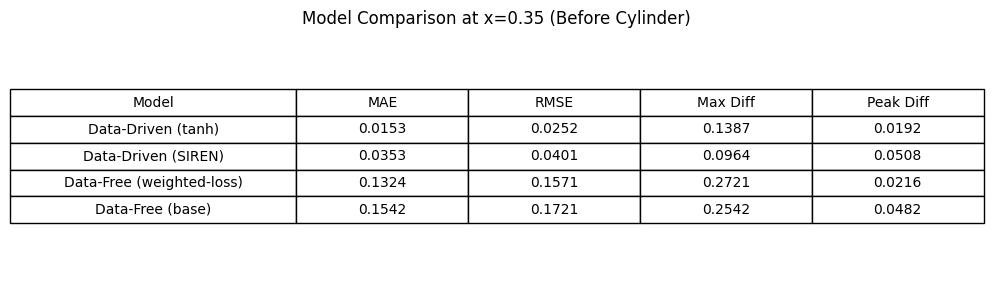


Metrics at x=0.75 (Behind Cylinder)
                    Model      MAE     RMSE  Max Diff  Peak Diff
       Data-Driven (tanh) 0.066499 0.083276  0.258114   0.125518
      Data-Driven (SIREN) 0.081340 0.101270  0.312576   0.065251
         Data-Free (base) 0.118604 0.151407  0.322955   0.134573
Data-Free (weighted-loss) 0.161881 0.184149  0.314968   0.222660


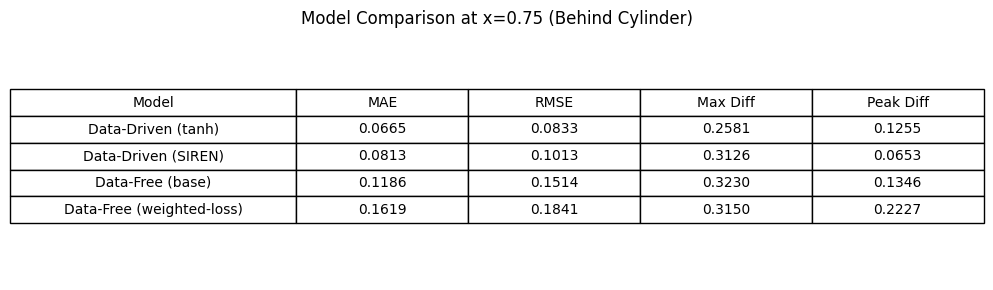

In [46]:
# Create focused tables for specific cross-sections of interest
focus_cross_sections = [0.35, 0.75]  # Before and after cylinder

for x_target in focus_cross_sections:
    # Create a table for this specific cross-section
    data = []
    for model_file in model_files:
        model_name = model_file.replace('.keras', '')
        model_label = legend_labels.get(model_name, model_name)
        
        # Find metrics for this model at this cross-section
        model_metrics = next((m for m in all_metrics[model_name] 
                             if m["cross_section"] == x_target), None)
        
        if model_metrics:
            row = {
                "Model": model_label,
                "MAE": model_metrics["MAE"],
                "RMSE": model_metrics["RMSE"],
                "Max Diff": model_metrics["max_diff"],
                "Peak Diff": model_metrics["peak_diff"]
            }
            data.append(row)
    
    # Create DataFrame and sort by MAE
    df = pd.DataFrame(data)
    df = df.sort_values(by="MAE")
    
    # Display the table
    print(f"\nMetrics at x={x_target} {'(Before Cylinder)' if x_target < 0.5 else '(Behind Cylinder)'}")
    print(df.to_string(index=False))
    
    # Save to CSV
    df.to_csv(f"metrics_at_x{x_target}.csv", index=False)
    
    # Create a cleaner table for the report
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    
    # Round only numeric columns, not the Model column
    numeric_cols = ['MAE', 'RMSE', 'Max Diff', 'Peak Diff']
    cell_text = []
    for i, row in df.iterrows():
        row_data = [row['Model']]  # First column (string)
        # Format numeric columns with 4 decimal places
        for col in numeric_cols:
            row_data.append(f"{row[col]:.4f}")
        cell_text.append(row_data)
    
    table = ax.table(
        cellText=cell_text,
        colLabels=df.columns,
        cellLoc='center',
        loc='center',
        colWidths=[0.25, 0.15, 0.15, 0.15, 0.15]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    plt.title(f"Model Comparison at x={x_target} {'(Before Cylinder)' if x_target < 0.5 else '(Behind Cylinder)'}")
    plt.tight_layout()
    plt.savefig(f"table_metrics_x{x_target}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

def enhanced_wake_metrics(x_grid, y_grid, u, v, p, model_name=""):
    wake_x_start = 0.6
    wake_x_end = 1.2
    wake_y_center = 0.65
    wake_y_half_width = 0.35
    wake_mask = ((x_grid >= wake_x_start) & (x_grid <= wake_x_end) &
                 (y_grid >= wake_y_center - wake_y_half_width) &
                 (y_grid <= wake_y_center + wake_y_half_width))
    metrics = {}
    u_wake = u[wake_mask]
    metrics['min_u_wake'] = float(np.min(u_wake))
    metrics['mean_u_wake'] = float(np.mean(u_wake))
    dy = y_grid[1, 0] - y_grid[0, 0]
    dx = x_grid[0, 1] - x_grid[0, 0]
    du_dy = np.gradient(u, dy, axis=0)
    dv_dx = np.gradient(v, dx, axis=1)
    vorticity = dv_dx - du_dy
    vorticity_wake = vorticity[wake_mask]
    metrics['max_vorticity_magnitude'] = float(np.max(np.abs(vorticity_wake)))
    metrics['mean_vorticity_magnitude'] = float(np.mean(np.abs(vorticity_wake)))
    centerline_idx = np.argmin(np.abs(y_grid[:, 0] - 0.5))
    u_centerline = u[centerline_idx, :]
    x_centerline = x_grid[centerline_idx, :]
    wake_centerline_mask = (x_centerline >= wake_x_start) & (x_centerline <= wake_x_end)
    u_wake_centerline = u_centerline[wake_centerline_mask]
    x_wake_centerline = x_centerline[wake_centerline_mask]
    sign_changes = np.sum(np.diff(np.sign(u_wake_centerline)) != 0)
    metrics['wake_sign_changes'] = int(sign_changes)
    recirculation_length = 0
    for i, x_val in enumerate(x_wake_centerline):
        if u_wake_centerline[i] > 0.01:
            recirculation_length = x_val - 0.6
            break
    metrics['recirculation_length'] = float(recirculation_length)
    upper_wake_mask = ((x_grid >= wake_x_start) & (x_grid <= wake_x_end) &
                       (y_grid >= wake_y_center) & (y_grid <= wake_y_center + wake_y_half_width))
    lower_wake_mask = ((x_grid >= wake_x_start) & (x_grid <= wake_x_end) &
                       (y_grid >= wake_y_center - wake_y_half_width) & (y_grid <= wake_y_center))
    u_upper = np.mean(u[upper_wake_mask])
    u_lower = np.mean(u[lower_wake_mask])
    metrics['wake_asymmetry'] = float(abs(u_upper - u_lower))
    metrics['model_name'] = model_name
    return metrics

def analyze_all_models(model_dir):
    model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])
    results = []
    for model_file in model_files:
        model_path = os.path.join(model_dir, model_file)
        print(f"Analyzing {model_file}")
        network = tf.keras.models.load_model(model_path)
        x = np.linspace(0, 2, 300)
        y = np.linspace(0, 1, 300)
        x_grid, y_grid = np.meshgrid(x, y)
        xy_flat = np.stack([x_grid.flatten(), y_grid.flatten()], axis=-1)
        u_v_p = network.predict(xy_flat, batch_size=len(xy_flat))
        u = u_v_p[..., 0].reshape(x_grid.shape)
        v = u_v_p[..., 1].reshape(x_grid.shape)
        p = u_v_p[..., 2].reshape(x_grid.shape)
        metrics = enhanced_wake_metrics(x_grid, y_grid, u, v, p, model_name=model_file)
        results.append(metrics)
    return pd.DataFrame(results)

# Usage
model_dir = "."
df_u = analyze_all_models(model_dir)
df_u

Analyzing OF_manual_lossset_02.keras
1/1 [==============================] - 0s 82ms/step
Analyzing SIREN_manual_lossset_03.keras
1/1 [==============================] - 0s 78ms/step
Analyzing base_re40.keras
1/1 [==============================] - 0s 84ms/step
Analyzing implicit_noroi_LC_cyl10.keras
1/1 [==============================] - 0s 79ms/step


,min_u_wake,mean_u_wake,max_vorticity_magnitude,mean_vorticity_magnitude,wake_sign_changes,recirculation_length,wake_asymmetry,model_name
0,-0.074649,0.638671,11.831478,4.365766,1,0.249498,0.418975,OF_manual_lossset_02.keras
1,-0.063520,0.621455,11.262129,3.449333,1,0.155853,0.372420,SIREN_manual_lossset_03.keras
2,-0.006519,0.657209,10.017725,2.775258,1,0.035452,0.100051,base_re40.keras
3,-0.005551,0.607868,9.198612,2.491607,1,0.028763,0.091136,implicit_noroi_LC_cyl10.keras


Analyzing OF_manual_lossset_02.keras
1/1 [==============================] - 0s 102ms/step


/home/u019642/anaconda3/envs/pinnpy_3.11/lib/python3.11/site-packages/matplotlib/patches.py:3436: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


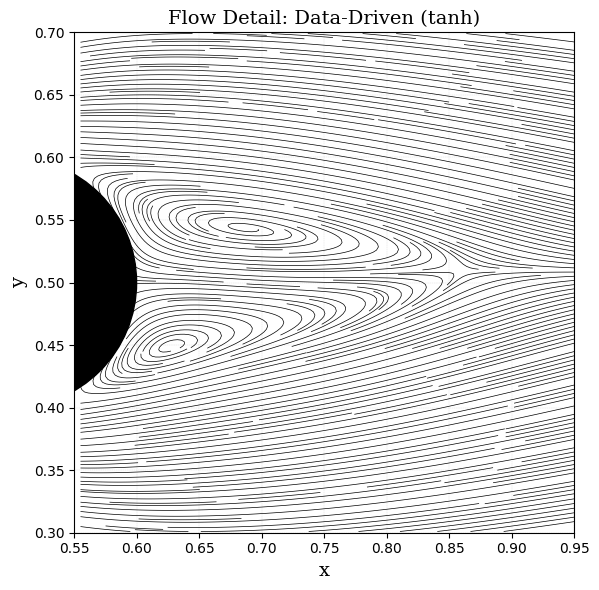

Analyzing SIREN_manual_lossset_03.keras
1/1 [==============================] - 0s 106ms/step


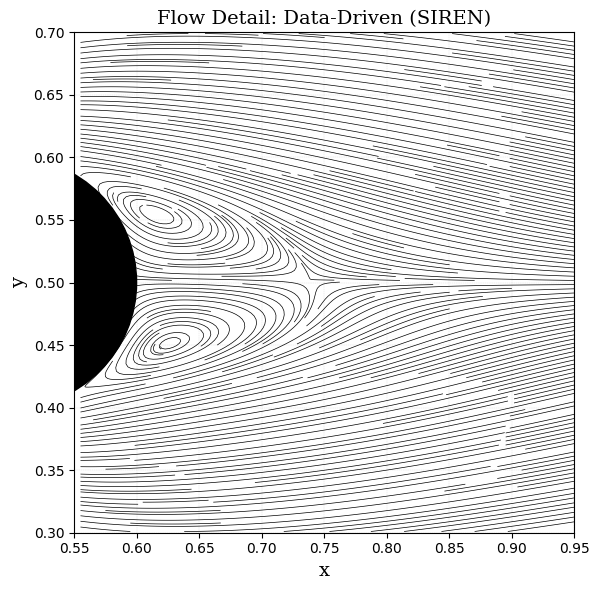

Analyzing base_re40.keras
1/1 [==============================] - 0s 96ms/step


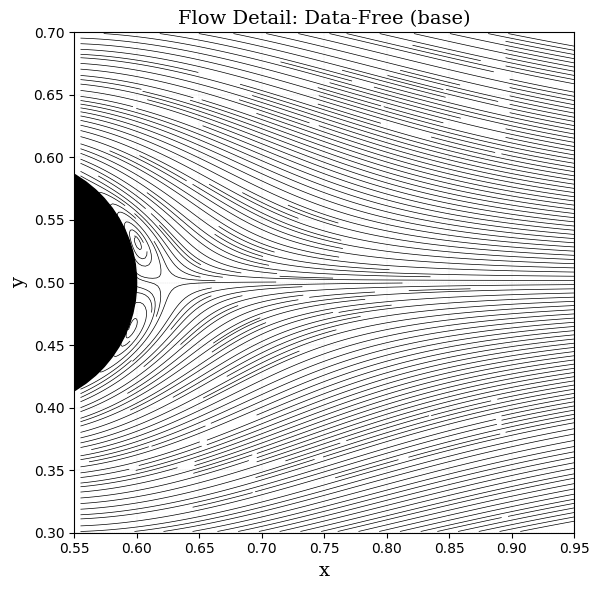

Analyzing implicit_noroi_LC_cyl10.keras
1/1 [==============================] - 0s 104ms/step


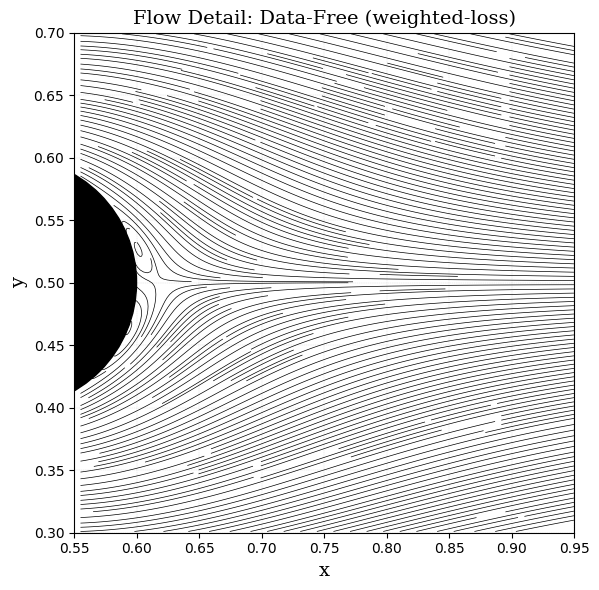

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import tensorflow as tf

# Define zoom box for streamline comparisons
xa, xb = 0.55, 0.95
ya, yb = 0.3, 0.7

# Define plotting parameters (smaller font size for smaller figures)
font1 = {'family': 'serif', 'size': 14}

# List of model files
model_dir = "/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison"
model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])
legend_labels = {
    "OF_manual_lossset_02": "Data-Driven (tanh)",
    "SIREN_manual_lossset_03": "Data-Driven (SIREN)",
    "implicit_noroi_LC_cyl10": "Data-Free (weighted-loss)",
    "base_re40": "Data-Free (base)"
}

# Process each model
for model_file in model_files:
    model_path = os.path.join(model_dir, model_file)
    print(f"Analyzing {model_file}")
    
    # Load model
    network = tf.keras.models.load_model(model_path)
    model_name = model_file.replace('.keras', '')
    model_label = legend_labels.get(model_name, model_name)
    
    # Create grid
    x = np.linspace(0, 2, 300)
    y = np.linspace(0, 1, 300)
    
    # Create mask for zoomed region
    x_zoom_idx = (x >= xa) & (x <= xb)
    y_zoom_idx = (y >= ya) & (y <= yb)
    
    # Extract points only in the zoom region (for efficiency)
    x_zoom = x[x_zoom_idx]
    y_zoom = y[y_zoom_idx]
    x_grid_zoom, y_grid_zoom = np.meshgrid(x_zoom, y_zoom)
    
    # Prepare input for model prediction
    xy_zoomed = np.stack([x_grid_zoom.flatten(), y_grid_zoom.flatten()], axis=-1)
    
    # Make predictions
    u_v_p_zoomed = network.predict(xy_zoomed, batch_size=len(xy_zoomed))
    
    # Reshape predictions to match zoomed grid
    u_zoom = u_v_p_zoomed[:, 0].reshape(x_grid_zoom.shape)
    v_zoom = u_v_p_zoomed[:, 1].reshape(x_grid_zoom.shape)
    
    # Create figure with transparent background (smaller size)
    fig = plt.figure(figsize=(8, 6), facecolor="none")
    ax = fig.add_subplot(111)
    ax.set_facecolor('none')  # Transparent axes background
    
    # Plot high-density streamlines in the zoomed region
    strm = ax.streamplot(
        x_grid_zoom, y_grid_zoom, u_zoom, v_zoom,
        density=4, color='k', linewidth=0.5, arrowsize=0
    )
    
    # Add cylinder
    ax.add_patch(Circle((0.5, 0.5), 0.1, color="black", zorder=5))
    
    # Configure plot
    plt.title(f"Flow Detail: {model_label}", fontdict=font1)
    plt.xlabel("x", fontdict=font1)
    plt.ylabel("y", fontdict=font1)
    plt.xlim(xa, xb)
    plt.ylim(ya, yb)
    ax.set_aspect('equal')
    
    # Add grid (very light for transparent background)
    plt.grid(color='gray', linestyle='--', linewidth=0.3, alpha=0.3)
    
    plt.tight_layout()
    
    # Save with transparent background
    plt.savefig(f"zoomed_flow_{model_name}.png", dpi=200, 
                bbox_inches='tight', transparent=True)
    plt.show()

Analyzing OF_manual_lossset_02.keras
1/1 [==============================] - 0s 99ms/step


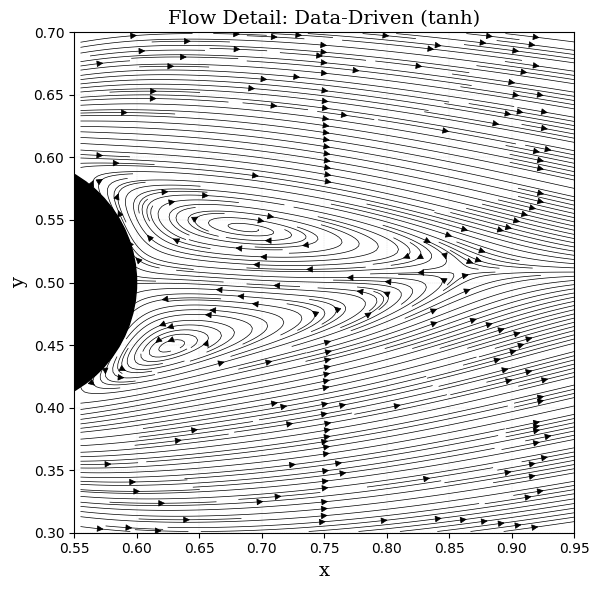

Analyzing SIREN_manual_lossset_03.keras
1/1 [==============================] - 0s 99ms/step


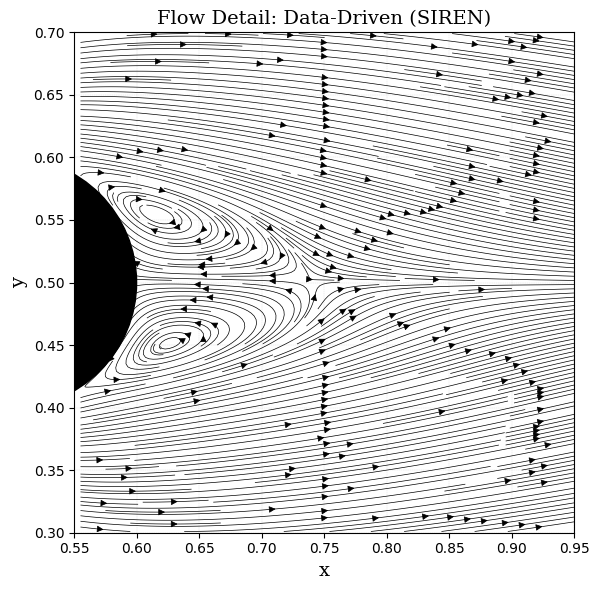

Analyzing base_re40.keras
1/1 [==============================] - 0s 90ms/step


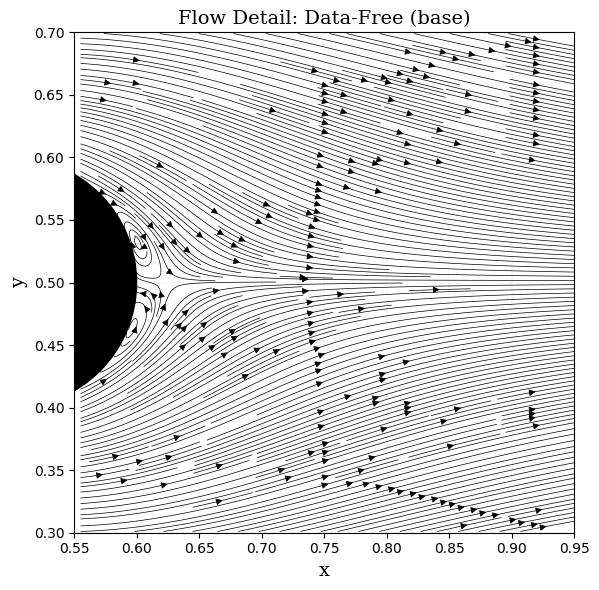

Analyzing implicit_noroi_LC_cyl60.keras
1/1 [==============================] - 0s 106ms/step


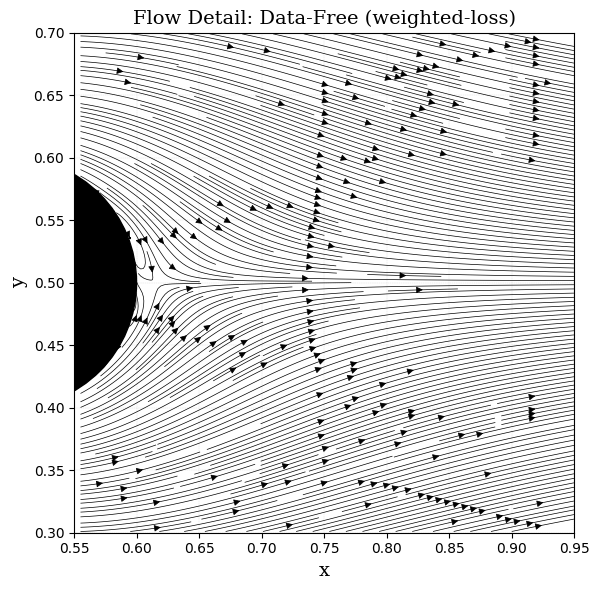

In [ ]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle
# import tensorflow as tf

# # Define zoom box for streamline comparisons
# xa, xb = 0.55, 0.95
# ya, yb = 0.3, 0.7

# # Define plotting parameters (smaller font size for smaller figures)
# font1 = {'family': 'serif', 'size': 14}

# # List of model files
# model_dir = "/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/Navier_Stokes_cylinder2D/trainings/model_comparison"
# model_files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])
# legend_labels = {
#     "OF_manual_lossset_02": "Data-Driven (tanh)",
#     "SIREN_manual_lossset_03": "Data-Driven (SIREN)",
#     "implicit_noroi_LC_cyl60": "Data-Free (weighted-loss)",
#     "base_re40": "Data-Free (base)"
# }

# # Process each model
# for model_file in model_files:
#     model_path = os.path.join(model_dir, model_file)
#     print(f"Analyzing {model_file}")
    
#     # Load model
#     network = tf.keras.models.load_model(model_path)
#     model_name = model_file.replace('.keras', '')
#     model_label = legend_labels.get(model_name, model_name)
    
#     # Create grid
#     x = np.linspace(0, 2, 300)
#     y = np.linspace(0, 1, 300)
    
#     # Create mask for zoomed region
#     x_zoom_idx = (x >= xa) & (x <= xb)
#     y_zoom_idx = (y >= ya) & (y <= yb)
    
#     # Extract points only in the zoom region (for efficiency)
#     x_zoom = x[x_zoom_idx]
#     y_zoom = y[y_zoom_idx]
#     x_grid_zoom, y_grid_zoom = np.meshgrid(x_zoom, y_zoom)
    
#     # Prepare input for model prediction
#     xy_zoomed = np.stack([x_grid_zoom.flatten(), y_grid_zoom.flatten()], axis=-1)
    
#     # Make predictions
#     u_v_p_zoomed = network.predict(xy_zoomed, batch_size=len(xy_zoomed))
    
#     # Reshape predictions to match zoomed grid
#     u_zoom = u_v_p_zoomed[:, 0].reshape(x_grid_zoom.shape)
#     v_zoom = u_v_p_zoomed[:, 1].reshape(x_grid_zoom.shape)
    
#     # Create figure with transparent background (smaller size)
#     fig = plt.figure(figsize=(8, 6), facecolor="none")
#     ax = fig.add_subplot(111)
#     ax.set_facecolor('none')  # Transparent axes background
    
#     # Plot high-density streamlines in the zoomed region
#     strm = ax.streamplot(x_grid_zoom, y_grid_zoom, u_zoom, v_zoom, 
#                         density=4, color='k', linewidth=0.5)
    
#     # Add cylinder
#     ax.add_patch(Circle((0.5, 0.5), 0.1, color="black", zorder=5))
    
#     # Configure plot
#     plt.title(f"Flow Detail: {model_label}", fontdict=font1)
#     plt.xlabel("x", fontdict=font1)
#     plt.ylabel("y", fontdict=font1)
#     plt.xlim(xa, xb)
#     plt.ylim(ya, yb)
#     ax.set_aspect('equal')
    
#     # Add grid (very light for transparent background)
#     plt.grid(color='gray', linestyle='--', linewidth=0.3, alpha=0.3)
    
#     plt.tight_layout()
    
#     # Save with transparent background
#     # plt.savefig(f"zoomed_flow_{model_name}.png", dpi=200, 
#     #             bbox_inches='tight', transparent=True)
#     plt.show()